In [1]:
# --- Cell 1: imports ---
import sys
import numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs import (DOMAINS, SOURCE_DOMAINS, TARGET_DOMAIN, CLASSES,
                         scan_domain, make_splits, find_domain_dir)

set_seed(6304)
DATA_ROOT = '../../datasets/PACS'

In [2]:
# --- Cell 2: sanity scan — ---
for d in DOMAINS:
    recs = scan_domain(DATA_ROOT, d)
    if d == TARGET_DOMAIN:
        # target CLASS labels stay closed until the final evaluation (Step 5);
        # the total is domain information, which the protocol permits
        print(f"{d:>13s}  n={len(recs):5d}  (per-class counts withheld: target labels)")
    else:
        counts = np.bincount([r['label'] for r in recs], minlength=len(CLASSES))
        print(f"{d:>13s}  n={len(recs):5d}  {dict(zip(CLASSES, counts.tolist()))}")
# expect: photo 1670, art_painting 2048, cartoon 2344, sketch 3929

        photo  n= 1670  {'dog': 189, 'elephant': 202, 'giraffe': 182, 'guitar': 186, 'horse': 199, 'house': 280, 'person': 432}
 art_painting  n= 2048  {'dog': 379, 'elephant': 255, 'giraffe': 285, 'guitar': 184, 'horse': 201, 'house': 295, 'person': 449}
      cartoon  n= 2344  {'dog': 389, 'elephant': 457, 'giraffe': 346, 'guitar': 135, 'horse': 324, 'house': 288, 'person': 405}
       sketch  n= 3929  (per-class counts withheld: target labels)


In [3]:
# --- Cell 3: build the 80/20 stratified splits and save them ---
splits = make_splits(DATA_ROOT, seed=6304, val_frac=0.2)

for d in SOURCE_DOMAINS:
    tr, va = splits['domains'][d]['train'], splits['domains'][d]['val']
    print(f"{d:>13s}  train={len(tr):5d}  val={len(va):4d}")
print(f"{TARGET_DOMAIN:>13s}  all={len(splits['domains'][TARGET_DOMAIN]['all']):5d} (unlabelled in Task 2)")

save_results(splits, '../../shared/splits/pacs_sketch_seed6304.json')

        photo  train= 1336  val= 334
 art_painting  train= 1638  val= 410
      cartoon  train= 1875  val= 469
       sketch  all= 3929 (unlabelled in Task 2)


In [4]:
# --- Cell 4: verification — leakage, stratification, class coverage ---
for d in SOURCE_DOMAINS:
    tr = splits['domains'][d]['train']
    va = splits['domains'][d]['val']
    tr_paths = {r['path'] for r in tr}
    va_paths = {r['path'] for r in va}

    overlap = tr_paths & va_paths
    tr_frac = np.bincount([r['label'] for r in tr], minlength=7) / len(tr)
    va_frac = np.bincount([r['label'] for r in va], minlength=7) / len(va)
    max_drift = np.abs(tr_frac - va_frac).max()   # how far stratification drifted

    print(f"{d:>13s}  overlap={len(overlap)}  unique={len(tr_paths | va_paths)}"
          f"  max class-proportion drift={max_drift:.4f}")
    assert len(overlap) == 0
    assert (np.bincount([r['label'] for r in va], minlength=7) > 0).all()

        photo  overlap=0  unique=1670  max class-proportion drift=0.0022
 art_painting  overlap=0  unique=2048  max class-proportion drift=0.0007
      cartoon  overlap=0  unique=2344  max class-proportion drift=0.0012


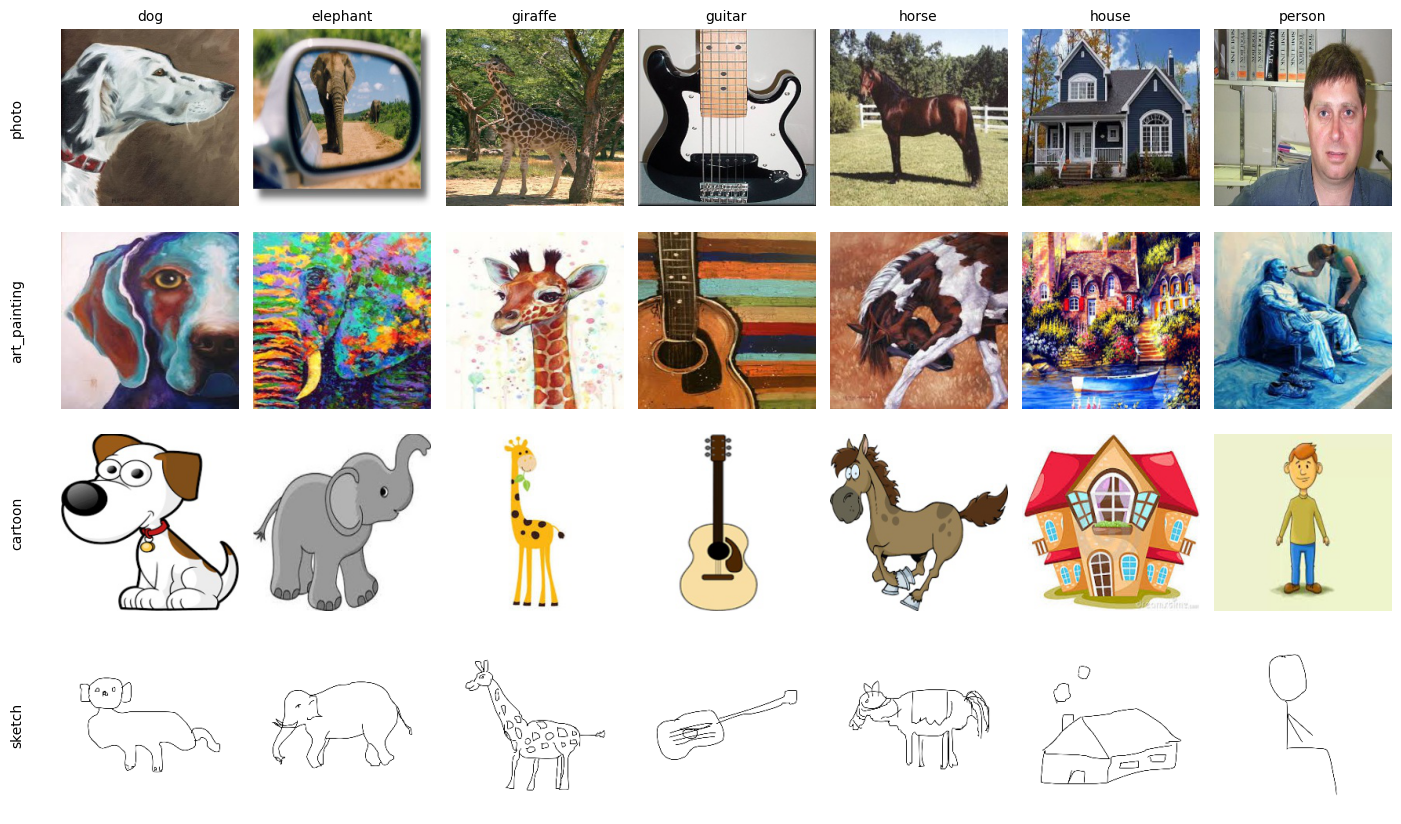

In [5]:
# --- Cell 5: look at the domain gap with your own eyes ---
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

fig, axes = plt.subplots(len(DOMAINS), len(CLASSES), figsize=(14, 8.5))
for r, d in enumerate(DOMAINS):
    recs = scan_domain(DATA_ROOT, d)
    for c, cls in enumerate(CLASSES):
        first = next(x for x in recs if x['label'] == c)
        axes[r, c].imshow(Image.open(Path(DATA_ROOT) / first['path']).convert('RGB'))
        axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(cls, fontsize=10)
    axes[r, 0].set_ylabel(d)
    axes[r, 0].text(-0.25, 0.5, d, transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../../report/figures/pacs_domains.png', dpi=200, bbox_inches='tight')
plt.show()